In [2]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
pi=np.pi
import librosa as lb
import soundfile as sf

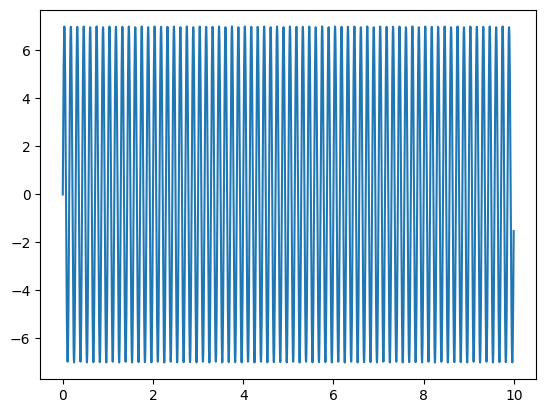

In [17]:
f1=8.5
f2=7

sr=200
duration=10
N=sr*duration

x=np.linspace(0,duration,N,endpoint=False)

y1=pi*np.sin(2*pi*f1*x+(pi/3))
y2=7*np.sin(2*pi*f2*x)
y=y2
plt.plot(x,y)

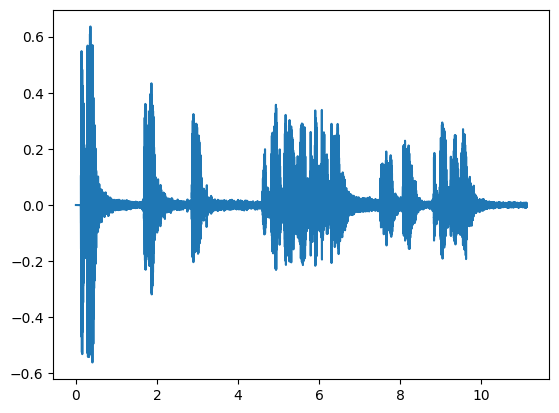

In [38]:
file = "Voice.wav"

# Load the file
# Note: librosa.load resamples to 22050Hz by default. 
# Use sr=None to keep the file's original sampling rate.
y, sr = lb.load(file, sr=None) 
x = np.arange(len(y)) / sr

plt.plot(x,y)

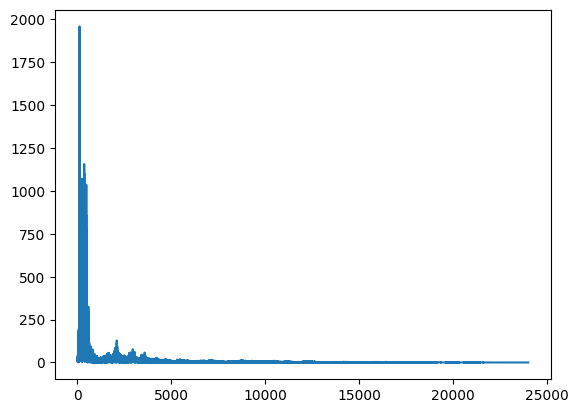

In [40]:
raw_fft = np.fft.fft(y)
len_raw_fft=len(raw_fft)
raw_fft = raw_fft[:len_raw_fft//2]

fft_abs = np.abs(raw_fft)
fft = fft_abs.tolist()

freq=np.fft.fftfreq(len(y),1/sr)
len_freq=len(freq)
freq=freq[:len_freq//2]

plt.plot(freq,fft)

In [46]:
def arctan(r,i):
    if i==0:
        return pi/2
    else:
        return float(np.arctan((r)/(i)))

d={}
for i in fft[0:2000]:
    c=raw_fft[fft.index(i)]
    f=float(freq[fft.index(i)])
    phase=arctan((c.real),(c.imag))
    amp=(2*i)/(len(y))
    d[f]=[amp,phase]
    
print(d)


{0.0: [0.00010469703079699327, 1.5707963267948966], 0.08992805755395684: [8.069456873882204e-05, -1.31239877469348], 0.1798561151079137: [8.228369810261902e-05, -1.1453925803936422], 0.26978417266187055: [7.692938183001254e-05, -0.8360936961689684], 0.3597122302158274: [7.789705953841194e-05, -0.5453128689112869], 0.4496402877697842: [7.95183911470353e-05, -0.4092046291687113], 0.5395683453237411: [8.038141693823585e-05, -0.24019031740358693], 0.6294964028776979: [7.944684859511514e-05, 0.029007409249846322], 0.7194244604316548: [7.093038292935547e-05, 0.23882844469480446], 0.8093525179856116: [7.723272534623884e-05, 0.48729990457134353], 0.8992805755395684: [7.565986516620871e-05, 0.7138220468655387], 0.9892086330935252: [7.539086795388054e-05, 0.9789313046748194], 1.0791366906474822: [7.804942116693287e-05, 1.1618323919719789], 1.169064748201439: [7.476342148014881e-05, 1.4927322764189912], 1.2589928057553958: [7.567962649264582e-05, -1.4249902197039892], 1.3489208633093526: [6.97884

==========  frequency 0.0 is done  ==========
==========  frequency 0.08992805755395684 is done  ==========
==========  frequency 0.1798561151079137 is done  ==========
==========  frequency 0.26978417266187055 is done  ==========
==========  frequency 0.3597122302158274 is done  ==========
==========  frequency 0.4496402877697842 is done  ==========
==========  frequency 0.5395683453237411 is done  ==========
==========  frequency 0.6294964028776979 is done  ==========
==========  frequency 0.7194244604316548 is done  ==========
==========  frequency 0.8093525179856116 is done  ==========
==========  frequency 0.8992805755395684 is done  ==========
==========  frequency 0.9892086330935252 is done  ==========
==========  frequency 1.0791366906474822 is done  ==========
==========  frequency 1.169064748201439 is done  ==========
==========  frequency 1.2589928057553958 is done  ==========
==========  frequency 1.3489208633093526 is done  ==========
==========  frequency 1.43884892086330

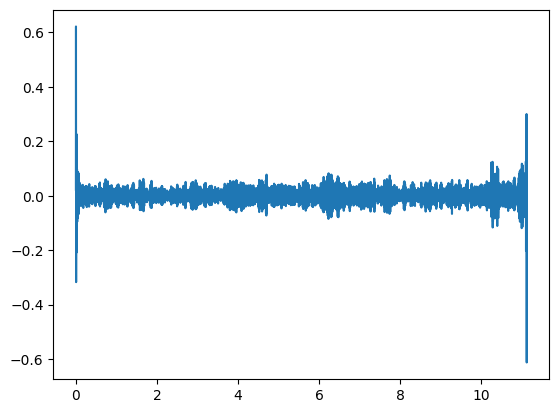

In [47]:
count=0
for i in list(d.keys()):
    if count==0:
        final = d[i][0]*np.sin(2*pi*(i)*x+d[i][1])
        count += 1
    else:
        final += d[i][0]*np.sin(2*pi*(i)*x+d[i][1])

    print(f"==========  frequency {i} is done  ==========")


plt.plot(x,final)

In [48]:
sf.write('output_song.wav', final, sr)
print("Done")

Done
